<h3 style="font-size:17px; font-weight:bold;">Rețele Neuronale Artificiale</h3>

<h5 style="font-size:14px;">

**Definiție:** Rețelele neuronale artificiale (RNA) sunt modele computaționale inspirate din funcționarea creierului uman, utilizate pentru a învăța relații complexe dintre datele de intrare și cele de ieșire. Ele sunt formate din neuroni artificiali organizați în straturi și sunt capabile să aproximeze funcții neliniare.  

**Tipuri:**<br>
- **Rețea neuronală feedforward (MLP – Multilayer Perceptron):** datele circulă într-o singură direcție (input → output), fără cicluri.<br>
- **Rețele neuronale convoluționale (CNN):** utilizate în special pentru procesarea imaginilor și datelor spațiale.<br>
- **Rețele neuronale recurente (RNN):** utilizate pentru date secvențiale (text, timp), având memorie internă.<br>
- **Rețele LSTM/GRU:** variante îmbunătățite ale RNN, capabile să învețe dependențe pe termen lung.<br>
- **Autoencodere:** folosite pentru reducerea dimensionalității și învățare nesupravegheată.<br>

**Elemente teoretice:**<br>
- **Neuron artificial:** unitate de bază care primește intrări, le ponderază și aplică o funcție de activare.<br>
- **Greutăți (weights):** coeficienți care determină importanța fiecărei intrări.<br>
- **Bias:** termen adițional care deplasează funcția de activare.<br>
- **Funcție de activare:** introduce neliniaritate (ex: ReLU, sigmoid, tanh).<br>
- **Straturi (layers):** input layer, hidden layers și output layer.<br>
- **Funcție de pierdere (loss):** măsoară eroarea dintre predicții și valorile reale.<br>
- **Backpropagation:** algoritm de antrenare care ajustează greutățile pe baza erorii.<br>
- **Rata de învățare (learning rate):** controlează cât de mult se actualizează greutățile la fiecare pas.<br>

**Presupuneri / caracteristici:**<br>
- **Nu necesită relații liniare:** pot modela relații complexe și neliniare.<br>
- **Necesită volum mare de date:** performanța crește cu mai multe date de antrenare.<br>
- **Generalizare:** capacitatea de a face predicții corecte pe date noi.<br>
- **Overfitting:** modelul poate învăța prea bine datele de antrenare și performează slab pe date noi.<br>
- **Regularizare:** tehnici (dropout, L2) pentru a preveni overfitting-ul.<br>
- **Scalare date:** datele de intrare trebuie normalizate pentru performanță optimă.<br><br>

</h5>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input

In [5]:
data = pd.read_csv('../data/churn_modelling.csv')

<h5 style="font-size:14px;">

**Descrierea setului de date:** Setul de date *Churn Modelling* conține informații despre clienții unei instituții financiare și este utilizat pentru a prezice probabilitatea ca un client să părăsească serviciile companiei (churn). Datele includ atât variabile descriptive, cât și variabile numerice relevante pentru analiza comportamentului clienților.

**Structura datelor:**<br>
- **RowNumber:** indexul înregistrării (fără relevanță analitică).<br>
- **CustomerId:** identificator unic al clientului.<br>
- **Surname:** numele clientului (variabilă descriptivă).<br>
- **Geography:** țara clientului (variabilă categorială).<br>
- **Gender:** genul clientului (variabilă categorială).<br>

**Variabile numerice utilizate în analiză:**<br>
- **CreditScore:** scorul de credit al clientului.<br>
- **Age:** vârsta clientului.<br>
- **Tenure:** numărul de ani în care clientul a fost înregistrat în companie.<br>
- **Balance:** soldul contului bancar.<br>
- **NumOfProducts:** numărul de produse utilizate de client.<br>
- **HasCrCard:** indică dacă clientul deține card de credit (0/1).<br>
- **IsActiveMember:** indică dacă clientul este activ (0/1).<br>
- **EstimatedSalary:** salariul estimat al clientului.<br>

**Variabilă țintă:**<br>
- **Exited:** indică dacă clientul a părăsit compania (1 = da, 0 = nu).<br>

**Observație:** În analiza cu rețele neuronale vor fi utilizate atât variabile numerice, cât și variabile categoriale (după codificare), deoarece aceste modele pot învăța relații complexe și neliniare între caracteristicile clienților și probabilitatea de churn.

</h5>

In [6]:
data.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [7]:
data.tail(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9990,9991,15798964,Nkemakonam,714,Germany,Male,33,3,35016.60,1,1,0,53667.08,0
9991,9992,15769959,Ajuluchukwu,597,France,Female,53,4,88381.21,1,1,0,69384.71,1
9992,9993,15657105,Chukwualuka,726,Spain,Male,36,2,0.00,1,1,0,195192.40,0
9993,9994,15569266,Rahman,644,France,Male,28,7,155060.41,1,1,0,29179.52,0
9994,9995,15719294,Wood,800,France,Female,29,2,0.00,2,0,0,167773.55,0
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
data.shape

(10000, 14)

In [11]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [12]:
data.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [13]:
data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [14]:
data.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [15]:
data.duplicated().sum()

0

In [16]:
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [17]:
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
data['Geography'] = le.fit_transform(data['Geography'])

In [18]:
x = data.drop('Exited', axis=1)
y = data['Exited']

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)

In [20]:
model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6527 - loss: 610.2042 - val_accuracy: 0.8057 - val_loss: 104.5590
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6798 - loss: 79.1317 - val_accuracy: 0.5329 - val_loss: 65.3136
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6830 - loss: 82.7939 - val_accuracy: 0.8057 - val_loss: 83.0507
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6750 - loss: 71.9501 - val_accuracy: 0.6693 - val_loss: 41.6895
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6759 - loss: 74.6608 - val_accuracy: 0.7650 - val_loss: 93.4469
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6889 - loss: 87.4368 - val_accuracy: 0.8007 - val_loss: 53.6987
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6784 - loss: 54.1978 - val_accuracy: 0.5321 - val_loss: 71.2249
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6775 - loss: 79.2890 -

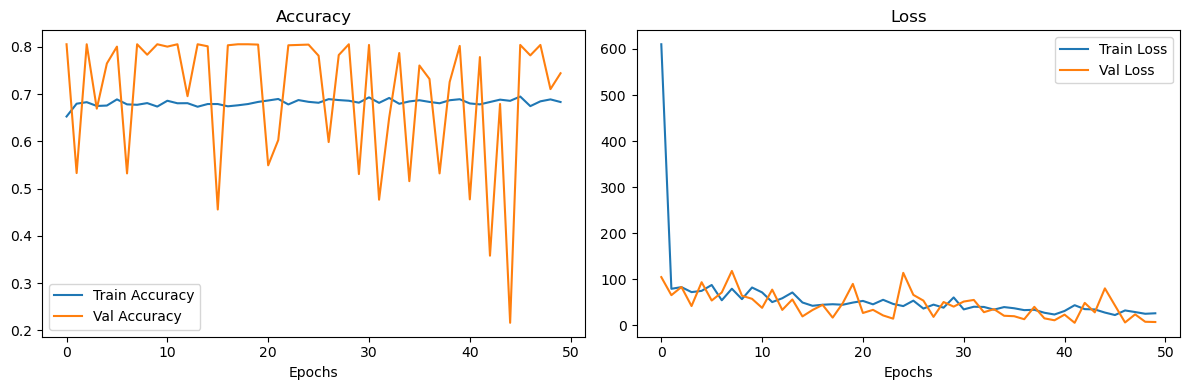

In [24]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.7256666666666667

Confusion Matrix:
 [[2036  342]
 [ 481  141]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83      2378
           1       0.29      0.23      0.26       622

    accuracy                           0.73      3000
   macro avg       0.55      0.54      0.54      3000
weighted avg       0.70      0.73      0.71      3000



In [26]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 0.6266786034019696, 1: 2.4734982332155475}


In [27]:
history2 = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

y_pred2 = (model.predict(x_test) > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("\nClassification Report:\n", classification_report(y_test, y_pred2))

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5232 - loss: 35.8394 - val_accuracy: 0.4500 - val_loss: 129.1665
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5243 - loss: 42.9014 - val_accuracy: 0.2836 - val_loss: 58.1947
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5218 - loss: 36.2253 - val_accuracy: 0.8007 - val_loss: 9.3596
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5337 - loss: 23.5355 - val_accuracy: 0.4636 - val_loss: 36.6631
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5348 - loss: 36.4780 - val_accuracy: 0.5136 - val_loss: 9.9067
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5298 - loss: 25.7040 - val_accuracy: 0.7986 - val_loss: 3.9646
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5400 - loss: 19.1654 - val_accuracy: 0.7014 - val_loss: 7.3502
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5202 - loss: 29.0972 - val_

In [28]:
model_opt = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model_opt.summary()

model_opt.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_opt = model_opt.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)


c:\Users\Costea\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,225 (47.75 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5164 - loss: 0.7955 - val_accuracy: 0.5793 - val_loss: 0.6909
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5111 - loss: 0.7504 - val_accuracy: 0.5243 - val_loss: 0.6664
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5286 - loss: 0.7272 - val_accuracy: 0.5457 - val_loss: 0.6728
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5268 - loss: 0.7143 - val_accuracy: 0.5214 - val_loss: 0.6886
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5446 - loss: 0.7017 - val_accuracy: 0.5071 - val_loss: 0.6754
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5205 - loss: 0.7047 - val_accuracy: 0.5114 - val_loss: 0.6706
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5145 - loss: 0.7041 - val_accuracy: 0.5050 - val_loss: 0.6836
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5138 - loss: 0.6969 - val_accu

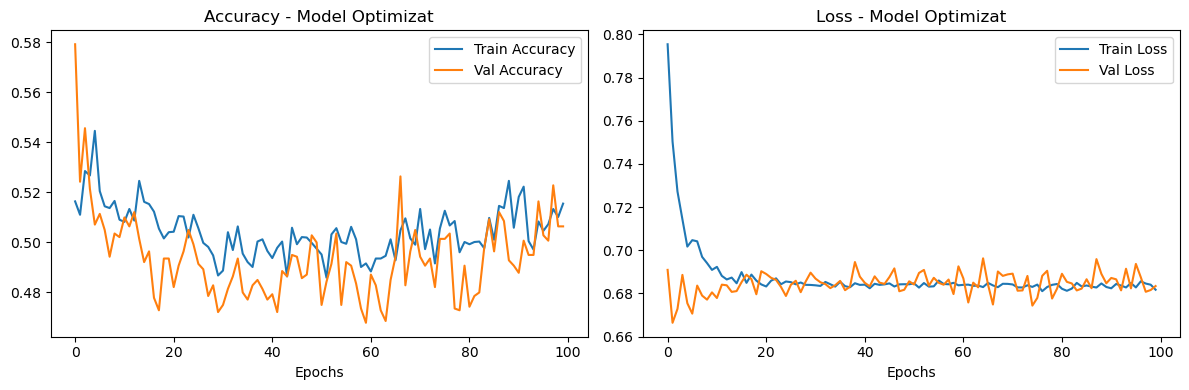

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.511

Confusion Matrix:
 [[1127 1251]
 [ 216  406]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.47      0.61      2378
           1       0.25      0.65      0.36       622

    accuracy                           0.51      3000
   macro avg       0.54      0.56      0.48      3000
weighted avg       0.72      0.51      0.55      3000



In [29]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_opt.history['accuracy'], label='Train Accuracy')
plt.plot(history_opt.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy - Model Optimizat')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_opt.history['loss'], label='Train Loss')
plt.plot(history_opt.history['val_loss'], label='Val Loss')
plt.title('Loss - Model Optimizat')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.show()

y_pred_opt = (model_opt.predict(x_test) > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_opt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_opt))